In [1]:
import os

import pandas as pd

genes_file = os.path.join("..", "..", "..", "Downloads", "five_utr_mutations.xlsx")
genes_df = pd.read_excel(genes_file, header=0)

genes_list = []
for gene in genes_df["Gene"]:
    if gene not in genes_list:
        genes_list.append(gene)

print(len(genes_list))



72


In [2]:
from utrfx.model import TxperGene

json_path = os.path.join("tests", "data", "Ensembl_transcript_per_gene_dictionary.json")

tx_per_gene_class  = TxperGene(json_path)

canonical_tx_per_gene_dict = {}
for gene in genes_list:
    canonical_tx_per_gene_dict[gene] = tx_per_gene_class.ensembl_transcript(gene)

print(canonical_tx_per_gene_dict)
print(len(canonical_tx_per_gene_dict))



{'NMNAT1': 'ENST00000377205.6', 'ALPL': 'ENST00000374840.8', 'PCSK9': 'ENST00000302118.5', 'ZNF644': 'ENST00000337393.10', 'SLC16A1': 'ENST00000369626.8', 'MYOC': 'ENST00000037502.11', 'IRF6': 'ENST00000367021.8', 'POMC': 'ENST00000395826.7', 'MSH2': 'ENST00000233146.7', 'SPR': 'ENST00000234454.6', 'REEP1': 'ENST00000538924.7', 'PROC': 'ENST00000234071.8', 'BMPR2': 'ENST00000374580.10', 'MLH1': 'ENST00000231790.8', 'KLHDC8B': 'ENST00000332780.4', 'ACAD9': 'ENST00000308982.12', 'THPO': 'ENST00000647395.1', 'TERT': 'ENST00000310581.10', 'ANKH': 'ENST00000284268.8', 'NIPBL': 'ENST00000282516.13', 'HTR1A': 'ENST00000323865.5', 'SLC26A2': 'ENST00000286298.5', 'RARS2': 'ENST00000369536.10', 'PEX7': 'ENST00000318471.5', 'SLC26A4': 'ENST00000644269.2', 'CFTR': 'ENST00000003084.11', 'LPL': 'ENST00000650287.1', 'HR': 'ENST00000381418.9', 'ANK1': 'ENST00000289734.13', 'CDKN2A': 'ENST00000304494.10', 'GRHPR': 'ENST00000318158.11', 'PRPF4': 'ENST00000374198.5', 'ENG': 'ENST00000373203.9', 'ANKRD26'

In [3]:
from utrfx.gtf_io import GTFio
from utrfx.genome import GRCh38

fpath_gtf = os.path.join("..", "..", "..", "Downloads", "Homo_sapiens.GRCh38.113.chr.gtf")

gtf_file = GTFio(fpath=fpath_gtf)
transcripts = gtf_file.extract_five_utrs_if_explicit(genome_build=GRCh38)


/Users/alejandropintoalba/Documents/project_utr/utrfx/src/utrfx/gtf_io.py:26: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf_df = pd.read_csv(self._fpath, sep = "\t", header = None, comment = "#")


In [4]:
from utrfx.util import fetch_cdna_from_ensembl, get_five_prime_sequence, uorf_extractor

tx_and_uofs_per_gene = {}
for gene, tx in canonical_tx_per_gene_dict.items():
    bare_tx = tx.split(".")[0]
    tx_cdna = fetch_cdna_from_ensembl(bare_tx)

    for tx in transcripts:
        if tx.tx_id == bare_tx:
            tx_found = tx
            break

    tx_five_utr_cdna = get_five_prime_sequence(tx_cdna, tx_found.five_utr)
    uorfs = uorf_extractor(tx_found.five_utr, tx_five_utr_cdna)

    tx_and_uofs_per_gene[gene] = [bare_tx, len(uorfs)]

In [5]:
print(tx_and_uofs_per_gene)

{'NMNAT1': ['ENST00000377205', 0], 'ALPL': ['ENST00000374840', 0], 'PCSK9': ['ENST00000302118', 1], 'ZNF644': ['ENST00000337393', 0], 'SLC16A1': ['ENST00000369626', 0], 'MYOC': ['ENST00000037502', 0], 'IRF6': ['ENST00000367021', 0], 'POMC': ['ENST00000395826', 0], 'MSH2': ['ENST00000233146', 0], 'SPR': ['ENST00000234454', 0], 'REEP1': ['ENST00000538924', 0], 'PROC': ['ENST00000234071', 1], 'BMPR2': ['ENST00000374580', 5], 'MLH1': ['ENST00000231790', 0], 'KLHDC8B': ['ENST00000332780', 2], 'ACAD9': ['ENST00000308982', 0], 'THPO': ['ENST00000647395', 2], 'TERT': ['ENST00000310581', 0], 'ANKH': ['ENST00000284268', 2], 'NIPBL': ['ENST00000282516', 3], 'HTR1A': ['ENST00000323865', 3], 'SLC26A2': ['ENST00000286298', 1], 'RARS2': ['ENST00000369536', 0], 'PEX7': ['ENST00000318471', 0], 'SLC26A4': ['ENST00000644269', 0], 'CFTR': ['ENST00000003084', 0], 'LPL': ['ENST00000650287', 0], 'HR': ['ENST00000381418', 4], 'ANK1': ['ENST00000289734', 0], 'CDKN2A': ['ENST00000304494', 0], 'GRHPR': ['ENST000

In [6]:
genes_with_uorfs = {}
genes_without_uorfs = {}

for gene, tx_uorfs in tx_and_uofs_per_gene.items():
    if tx_uorfs[1] >= 1:
        genes_with_uorfs[gene] = tx_uorfs
    else:
        genes_without_uorfs[gene] = tx_uorfs

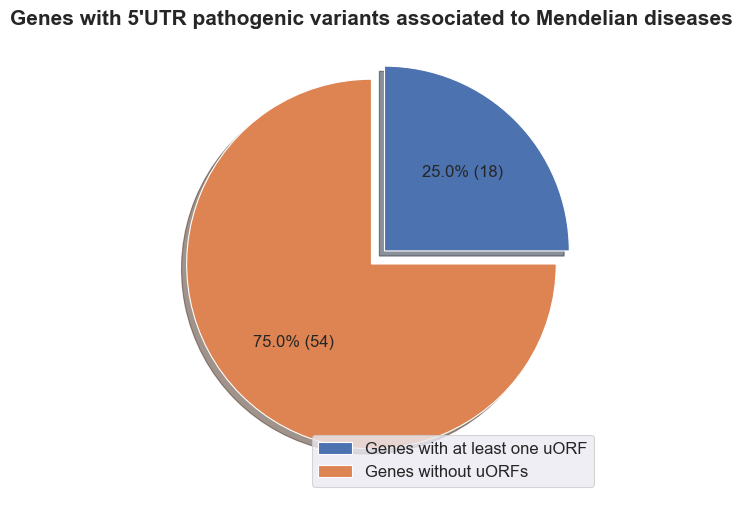

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

data = [len(genes_with_uorfs), len(genes_without_uorfs)]
labels = ["Genes with at least one uORF", "Genes without uORFs"]
explode = (0.1, 0)

def autopct_with_value(pct, allvals):
    absolute = round(pct / 100.*sum(allvals)) 
    return f'{pct}% ({absolute})'

sns.set("paper")
plt.figure(figsize=(6,6))
plt.pie(data, 
        labels=labels, 
        labeldistance=None, 
        explode=explode, 
        shadow=True, 
        autopct=lambda pct: autopct_with_value(pct, data),
        textprops={"fontsize": 12},
        radius=1,
    )
plt.legend(loc= "lower right",
           fontsize=12)
plt.title("Genes with 5'UTR pathogenic variants associated to Mendelian diseases",
          fontsize= 15,
          fontweight= "bold",)
plt.show()

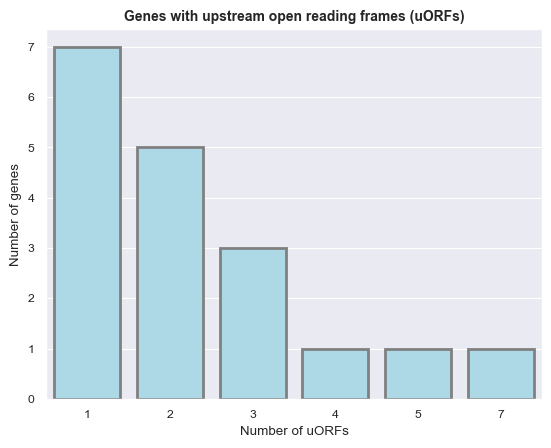

In [8]:
data = {}

for tx, uorf in genes_with_uorfs.values():
    if uorf not in data:
        data[uorf] = 1
    else:
        data[uorf] += 1

df = pd.DataFrame(list(data.items()), columns=["Number of uORFs", "Number of genes"])

sns.barplot(data=df, 
            x="Number of uORFs", 
            y="Number of genes",
            linewidth=2, edgecolor=".5", facecolor="lightblue",            
        )
plt.title("Genes with upstream open reading frames (uORFs)",
          fontsize=10,
          fontweight="bold",
        )
plt.show()

In [9]:
genes_with_uorfs_df = genes_df[genes_df["Gene"].isin(genes_with_uorfs.keys())]

print(genes_with_uorfs_df.head())

     Chr   Position  Ref  Alt     Gene
3   chr1   55039507    C    A    PCSK9
12  chr2  127418425    T    C     PROC
13  chr2  202376527  GGC  GAT    BMPR2
14  chr2  202376806    G    A    BMPR2
18  chr3   49171662    C    T  KLHDC8B


In [10]:
chr_of_genes_with_uorfs = []
number_variants_for_chr_with_uorfs_dict = {}

for chr in genes_with_uorfs_df["Chr"]:
    if chr not in chr_of_genes_with_uorfs:
        chr_of_genes_with_uorfs.append(chr)
    if chr not in number_variants_for_chr_with_uorfs_dict:
        number_variants_for_chr_with_uorfs_dict[chr] = 1
    else:
        number_variants_for_chr_with_uorfs_dict[chr] += 1

number_variants_genes_with_uorf = 0
for num in number_variants_for_chr_with_uorfs_dict.values():
    number_variants_genes_with_uorf += num

print(chr_of_genes_with_uorfs)
print(number_variants_for_chr_with_uorfs_dict)
print(number_variants_genes_with_uorf)


['chr1', 'chr2', 'chr3', 'chr5', 'chr8', 'chr10', 'chr11', 'chr14', 'chrX']
{'chr1': 1, 'chr2': 3, 'chr3': 3, 'chr5': 4, 'chr8': 13, 'chr10': 9, 'chr11': 2, 'chr14': 2, 'chrX': 6}
43


In [11]:
import csv

from utrfx.genome import GRCh38, VariantCoordinates, GenomeBuild, Strand
from utrfx.util import fetch_cdna_from_ensembl, get_five_prime_sequence, uorf_extractor
from utrfx.uorf import gc_content, gc_content_n_bases_downstream, intercistronic_distance, cap_five_to_uorf_distance, kozak_sequence_strength  
from utrfx.variant_util import prepare_alt_seq, VCFfile

output_fpath = os.path.join("tests", "data", "Results.tsv")
variant_file = os.path.join("..", "..", "..", "Downloads", "five_utr_mutations.xlsx")
vcf_fpath = os.path.join("..", "..", "..", "Downloads", "gnomad.joint.v4.1.sites.chr1.vcf.bgz")

max_uorfs = 7 
header = ["tx_id", "Pathogenicity proved", "Type mutation", "NuORFs"]
for i in range(max_uorfs):
    header += [f"{i}uORF_length", f"{i}Is_ouORF", f"{i}GC", f"{i}GCplus", f"{i}ID", f"{i}Cap_distance", f"{i}Kozak"]

with open(output_fpath, "w", newline='') as file:
    writer = csv.writer(file, delimiter='\t')
    writer.writerow(header)

gene = None
tx_id = None
tx_id_clean = None
five_utr_cdna_sequence = None
contig = None
variants_id_list = []
for _, row in genes_with_uorfs_df.iterrows():
    if gene is None or row["Gene"] != gene:
        variants_id_list = []
        gene = row["Gene"]
        tx_id = TxperGene(fpath=json_path).ensembl_transcript(gene_symbol=row["Gene"])
        contig = GenomeBuild.contig_by_name(GRCh38, name= str(row["Chr"]))
        
        tx_id_clean = tx_id.split(".")[0]
        for tx in transcripts:
            if tx.tx_id == tx_id_clean:
                tx_found = tx
                break
        
        assert tx_found is not None, "Transcript not found"

        tx_cdna_sequence = fetch_cdna_from_ensembl(transcript_id=tx_id_clean)
        five_utr_cdna_sequence = get_five_prime_sequence(cdna_sequence=tx_cdna_sequence, five_utrs=tx_found.five_utr)

        results_tx = []
        tx_id_tsv = tx_id_clean + "-" + str(row["Chr"])
        results_tx.append(tx_id_tsv)
        results_tx.append("")
        results_tx.append("canonical")

        uorfs = uorf_extractor(five_utr=tx_found.five_utr, five_sequence=five_utr_cdna_sequence)
        results_tx.append(len(uorfs))
        canonical_number_uorfs = len(uorfs)

        canonical_uorf_lengths = []

        for uorf in uorfs:
            results_tx.append(uorf.uorf.end - uorf.uorf.start)
            canonical_uorf_lengths.append(uorf.uorf.end - uorf.uorf.start)
            results_tx.append(uorf.ouorf)
            results_tx.append(gc_content(five_sequence=five_utr_cdna_sequence, uorf=uorf))
            results_tx.append(gc_content_n_bases_downstream(five_sequence=five_utr_cdna_sequence, uorf=uorf, bases=10))
            results_tx.append(intercistronic_distance(five_sequence=five_utr_cdna_sequence, uorf=uorf))
            results_tx.append(cap_five_to_uorf_distance(uorf=uorf))
            results_tx.append(kozak_sequence_strength(five_sequence=five_utr_cdna_sequence, uorf=uorf))      

        while len(results_tx) < len(header):
            results_tx.append(float("nan"))      

        with open(output_fpath, "a", newline='') as file:
            writer = csv.writer(file, delimiter='\t')
            writer.writerow(results_tx)

    variant = VariantCoordinates.from_vcf_literal(contig, row["Position"], row["Ref"], row["Alt"])
    variant_tx_id = tx_id_clean + "-" + str(row["Chr"]) + "-" + str(row["Position"]) + "-" + row["Ref"] + "-" + row["Alt"]
    variants_id_list.append(variant_tx_id)
    variant_results = []
    variant_results.append(variant_tx_id)
    variant_results.append("Yes")

    variant_five_utr_sequence = prepare_alt_seq(variant, five_utr_cdna_sequence, tx_found.five_utr)

    if variant_five_utr_sequence == "Variant not in the 5'UTR of the given transcript":
        variant_results.append("Variant not in the 5'UTR of the given transcript")

        with open(output_fpath, "a", newline='') as file:
            writer = csv.writer(file, delimiter='\t')
            writer.writerow(variant_results)
    else:
        if variant_five_utr_sequence == "Reference alleles do not match":
            variant_results.append("Reference alleles do not match")

            with open(output_fpath, "a", newline='') as file:
                writer = csv.writer(file, delimiter='\t')
                writer.writerow(variant_results)
        else:
            variant_uorfs = uorf_extractor(five_utr=tx_found.five_utr, five_sequence=variant_five_utr_sequence)
            variant_results.append(len(variant_uorfs))
            variant_number_uorfs = len(variant_uorfs)
            variant_uorf_lengths = []
            for uorf in variant_uorfs:
                variant_results.append(uorf.uorf.end - uorf.uorf.start)
                variant_uorf_lengths.append(uorf.uorf.end - uorf.uorf.start)
                variant_results.append(uorf.ouorf)
                variant_results.append(gc_content(five_sequence=variant_five_utr_sequence, uorf=uorf))
                variant_results.append(gc_content_n_bases_downstream(five_sequence=variant_five_utr_sequence, uorf=uorf, bases=10))
                variant_results.append(intercistronic_distance(five_sequence=variant_five_utr_sequence, uorf=uorf))
                variant_results.append(cap_five_to_uorf_distance(uorf=uorf))
                variant_results.append(kozak_sequence_strength(five_sequence=variant_five_utr_sequence, uorf=uorf))
            
            if variant_number_uorfs > canonical_number_uorfs:
                variant_results.insert(2, "start codon gain mutation")
            elif variant_number_uorfs < canonical_number_uorfs:
                variant_results.insert(2, "start codon loss mutation")

            if isinstance(variant_results[2], int):
                for length1, length2 in zip(canonical_uorf_lengths, variant_uorf_lengths):
                    if length1 > length2:
                        variant_results.insert(2, "stop codon gain mutation")
                    elif length1 < length2:
                        variant_results.insert(2, "stop codon loss mutation")
            
            if isinstance(variant_results[2], int):
                variant_results.insert(2, "missense mutation")

            while len(variant_results) < len(header):
                variant_results.append(float("nan"))

            with open(output_fpath, "a", newline='') as file:
                writer = csv.writer(file, delimiter='\t')
                writer.writerow(variant_results)

    # with VCFfile(vcf_fpath) as variant_file:
    #     for region in tx_found.five_utr.regions:
    #         vcf_variants = variant_file.retrieve_variants_of_region(contig=contig, start=region.start_on_strand(Strand.POSITIVE), end=region.end_on_strand(Strand.POSITIVE))
    #         if vcf_variants:
    #             for variant in vcf_variants:
    #                 vcf_variant_tx_id = tx_id_clean + "-" + variant.chrom + "-" + str(variant.start) + "-" + variant.ref + "-" + variant.alt

    #                 if vcf_variant_tx_id not in variants_id_list:
    #                     vcf_variant = VariantCoordinates.from_vcf_literal(contig, variant.start, variant.ref, variant.alt)
    #                     vcf_variant_results = []
    #                     vcf_variant_results.append(vcf_variant_tx_id)
    #                     vcf_variant_results.append("No")

    #                     variant_five_utr_sequence = prepare_alt_seq(vcf_variant, five_utr_cdna_sequence, tx_found.five_utr)

    #                     vcf_variant_uorfs = uorf_extractor(five_utr=tx_found.five_utr, five_sequence=variant_five_utr_sequence)
    #                     vcf_variant_results.append(len(vcf_variant_uorfs))
    #                     vcf_variant_number_uorfs = len(vcf_variant_uorfs)
    #                     vcf_variant_uorf_lengths = []
    #                     for uorf in vcf_variant_uorfs:
    #                         vcf_variant_results.append(uorf.uorf.end - uorf.uorf.start)
    #                         vcf_variant_uorf_lengths.append(uorf.uorf.end - uorf.uorf.start)
    #                         vcf_variant_results.append(uorf.ouorf)
    #                         vcf_variant_results.append(gc_content(five_sequence=variant_five_utr_sequence, uorf=uorf))
    #                         vcf_variant_results.append(gc_content_n_bases_downstream(five_sequence=variant_five_utr_sequence, uorf=uorf, bases=10))
    #                         vcf_variant_results.append(intercistronic_distance(five_sequence=variant_five_utr_sequence, uorf=uorf))
    #                         vcf_variant_results.append(cap_five_to_uorf_distance(uorf=uorf))
    #                         vcf_variant_results.append(kozak_sequence_strength(five_sequence=variant_five_utr_sequence, uorf=uorf))
                        
    #                     if vcf_variant_number_uorfs > canonical_number_uorfs:
    #                         vcf_variant_results.insert(2, "start codon gain mutation")
    #                     elif vcf_variant_number_uorfs < canonical_number_uorfs:
    #                         vcf_variant_results.insert(2, "start codon loss mutation")

    #                     if isinstance(vcf_variant_results[2], int):
    #                         for length1, length2 in zip(canonical_uorf_lengths, vcf_variant_uorf_lengths):
    #                             if length1 > length2:
    #                                 vcf_variant_results.insert(2, "stop codon gain mutation")
    #                             elif length1 < length2:
    #                                 vcf_variant_results.insert(2, "stop codon loss mutation")
                        
    #                     if isinstance(vcf_variant_results[2], int):
    #                                 vcf_variant_results.insert(2, "missense mutation")

    #                     while len(vcf_variant_results) < len(header):
    #                         vcf_variant_results.append(float("nan"))

    #                     with open(output_fpath, "a", newline='') as file:
    #                         writer = csv.writer(file, delimiter='\t')
    #                         writer.writerow(vcf_variant_results)


In [12]:
variants_genes_with_uorfs_df = pd.read_csv(output_fpath, delimiter="\t", header=0, index_col=0)

canonical_tx_genes_with_uorfs_df = variants_genes_with_uorfs_df[variants_genes_with_uorfs_df["Type mutation"] == "canonical"]
pathogenic_variants_genes_with_uorfs_df = variants_genes_with_uorfs_df[variants_genes_with_uorfs_df["Pathogenicity proved"] == "Yes"]

print(pathogenic_variants_genes_with_uorfs_df.head())

                                       Pathogenicity proved  \
tx_id                                                         
ENST00000302118-chr1-55039507-C-A                       Yes   
ENST00000234071-chr2-127418425-T-C                      Yes   
ENST00000374580-chr2-202376527-GGC-GAT                  Yes   
ENST00000374580-chr2-202376806-G-A                      Yes   
ENST00000332780-chr3-49171662-C-T                       Yes   

                                                                           Type mutation  \
tx_id                                                                                      
ENST00000302118-chr1-55039507-C-A       Variant not in the 5'UTR of the given transcript   
ENST00000234071-chr2-127418425-T-C      Variant not in the 5'UTR of the given transcript   
ENST00000374580-chr2-202376527-GGC-GAT                         start codon gain mutation   
ENST00000374580-chr2-202376806-G-A                                     missense mutation   
ENST00

In [13]:
type_mutations_pathogenic_variants_with_uorfs_dict = {}
for type_mutation in pathogenic_variants_genes_with_uorfs_df["Type mutation"]:
    if type_mutation not in type_mutations_pathogenic_variants_with_uorfs_dict:
        type_mutations_pathogenic_variants_with_uorfs_dict[type_mutation] = 1
    else:
        type_mutations_pathogenic_variants_with_uorfs_dict[type_mutation] += 1

print(type_mutations_pathogenic_variants_with_uorfs_dict)

{"Variant not in the 5'UTR of the given transcript": 9, 'start codon gain mutation': 3, 'missense mutation': 17, 'stop codon gain mutation': 3, 'Reference alleles do not match': 2, 'start codon loss mutation': 5, 'stop codon loss mutation': 4}


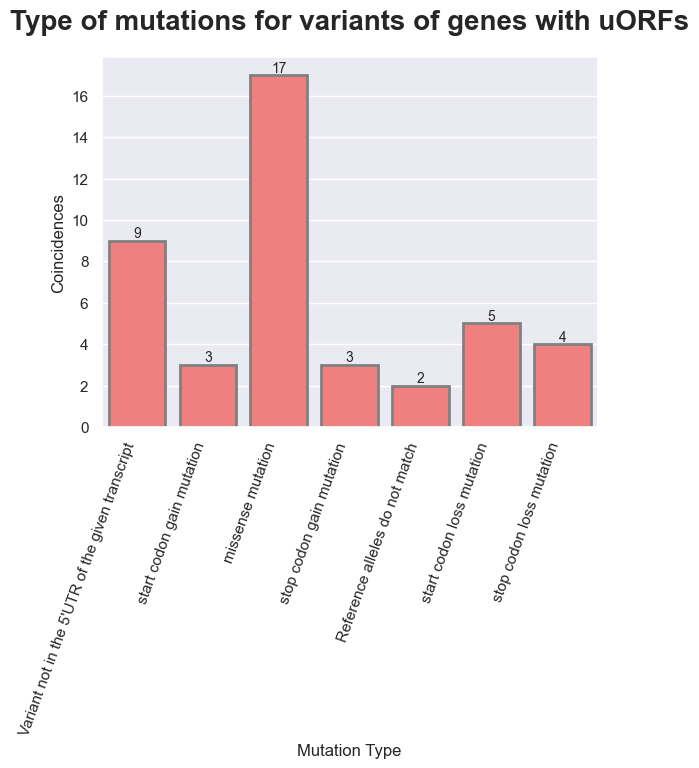

In [90]:
data_two = []
labels_two = []
for label, value in type_mutations_pathogenic_variants_with_uorfs_dict.items():
    labels_two.append(label)
    data_two.append(value)

type_mutations_pathogenic_variants_with_uorfs_df = pd.DataFrame(zip(labels_two, data_two), columns=["Mutation Type", "Coincidences"])

sns.set_theme()
ax = sns.barplot(data=type_mutations_pathogenic_variants_with_uorfs_df, 
            x="Mutation Type",  # Labels on the x-axis
            y="Coincidences",  # Values on the y-axis
            linewidth=2, 
            edgecolor=".5", 
            facecolor="lightcoral",)

plt.title("Type of mutations for variants of genes with uORFs",
          fontsize=20,
          fontweight="bold",
          pad=20,
         )
ax.bar_label(ax.containers[0], fontsize=10)
plt.xticks(rotation=70, ha="right") 
plt.show()

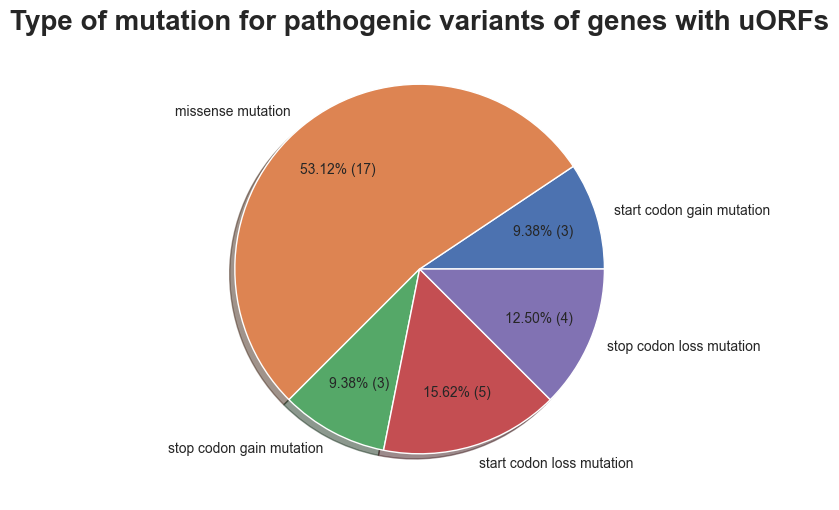

In [114]:
mutations_pathogenic_variants_df = type_mutations_pathogenic_variants_with_uorfs_df[
    (type_mutations_pathogenic_variants_with_uorfs_df["Mutation Type"] != "Variant not in the 5'UTR of the given transcript") &
    (type_mutations_pathogenic_variants_with_uorfs_df["Mutation Type"] != 'Reference alleles do not match')
]


sns.set("notebook")
plt.figure(figsize=(6,6))
plt.pie(mutations_pathogenic_variants_df["Coincidences"], 
        labels=mutations_pathogenic_variants_df["Mutation Type"], 
        labeldistance=1.1, 
        shadow=True, 
        autopct=lambda pct: autopct_with_value(pct, mutations_pathogenic_variants_df["Coincidences"]),
        textprops={"fontsize": 10},
        pctdistance=0.7,
        radius=1,
    )
plt.title("Type of mutation for pathogenic variants of genes with uORFs",
          fontsize= 20,
          fontweight= "bold",)
plt.show()

In [15]:
vcf_fpath = os.path.join("..", "..", "..", "Downloads", "gnomad.joint.v4.1.sites.chr1.vcf.bgz")

with VCFfile(vcf_fpath) as variant_file:
    for region in tx_found.five_utr.regions:
        vcf_variants = variant_file.retrieve_variants_of_region(contig=contig, start=region.start_on_strand(Strand.POSITIVE), end=region.end_on_strand(Strand.POSITIVE))
        if vcf_variants:
            for variant in vcf_variants:
                vcf_variant_tx_id = tx_id_clean + "-" + variant.chrom + "-" + str(variant.start) + "-" + variant.ref + "-" + variant.alt

                if vcf_variant_tx_id not in variants_id_list:
                    vcf_variant = VariantCoordinates.from_vcf_literal(contig, variant.start, variant.ref, variant.alt)
                    vcf_variant_results = []
                    vcf_variant_results.append(vcf_variant_tx_id)
                    vcf_variant_results.append("No")

                    variant_five_utr_sequence = prepare_alt_seq(vcf_variant, five_utr_cdna_sequence, tx_found.five_utr)

                    vcf_variant_uorfs = uorf_extractor(five_utr=tx_found.five_utr, five_sequence=variant_five_utr_sequence)
                    vcf_variant_results.append(len(vcf_variant_uorfs))
                    vcf_variant_number_uorfs = len(vcf_variant_uorfs)
                    vcf_variant_uorf_lengths = []
                    for uorf in vcf_variant_uorfs:
                        vcf_variant_results.append(uorf.uorf.end - uorf.uorf.start)
                        vcf_variant_uorf_lengths.append(uorf.uorf.end - uorf.uorf.start)
                        vcf_variant_results.append(uorf.ouorf)
                        vcf_variant_results.append(gc_content(five_sequence=variant_five_utr_sequence, uorf=uorf))
                        vcf_variant_results.append(gc_content_n_bases_downstream(five_sequence=variant_five_utr_sequence, uorf=uorf, bases=10))
                        vcf_variant_results.append(intercistronic_distance(five_sequence=variant_five_utr_sequence, uorf=uorf))
                        vcf_variant_results.append(cap_five_to_uorf_distance(uorf=uorf))
                        vcf_variant_results.append(kozak_sequence_strength(five_sequence=variant_five_utr_sequence, uorf=uorf))
                    
                    if vcf_variant_number_uorfs > canonical_number_uorfs:
                        vcf_variant_results.insert(2, "start codon gain mutation")
                    elif vcf_variant_number_uorfs < canonical_number_uorfs:
                        vcf_variant_results.insert(2, "start codon loss mutation")

                    if isinstance(vcf_variant_results[2], int):
                        for length1, length2 in zip(canonical_uorf_lengths, vcf_variant_uorf_lengths):
                            if length1 > length2:
                                vcf_variant_results.insert(2, "stop codon gain mutation")
                            elif length1 < length2:
                                vcf_variant_results.insert(2, "stop codon loss mutation")
                    
                    if isinstance(vcf_variant_results[2], int):
                                vcf_variant_results.insert(2, "missense mutation")

                    while len(vcf_variant_results) < len(header):
                        vcf_variant_results.append(float("nan"))

                    with open(output_fpath, "a", newline='') as file:
                        writer = csv.writer(file, delimiter='\t')
                        writer.writerow(vcf_variant_results)